# Model Evaluation

This notebook evaluates the performance of the trained machine learning models for crop yield prediction. The models are compared using common regression evaluation metrics to determine which provides the most accurate predictions.

The models evaluated are:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

In [9]:
# Import required libraries

import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import matplotlib.pyplot as plt
import seaborn as sns

## Load the Test Datasets

The preprocessed testing datasets created during the preprocessing stage are loaded. The scaled dataset is used for evaluating the Linear Regression model, while the unscaled dataset is used for the tree-based models.

In [11]:
# Load testing datasets

X_test = pd.read_csv("../Data/Processed_data/X_test.csv")
y_test = pd.read_csv("../Data/Processed_data/y_test.csv").squeeze()

X_test_scaled = pd.read_csv("../Data/Processed_data/X_test_scaled.csv")

print("Testing set:", X_test.shape)
print("Scaled testing set:", X_test_scaled.shape)
print("Target:", y_test.shape)

Testing set: (303, 15)
Scaled testing set: (303, 15)
Target: (303,)


## Load the Trained Models

The previously trained machine learning models are loaded from the `models` directory. These models will be used to generate predictions on the testing dataset.

In [12]:
# Load trained models

linear_model = joblib.load("../models/linear_regression_model.pkl")

random_forest_model = joblib.load(
    "../models/random_forest_model.pkl"
)

gradient_boosting_model = joblib.load(
    "../models/gradient_boosting_model.pkl"
)

xgboost_model = joblib.load(
    "../models/xgboost_model.pkl"
)

print("All models loaded successfully!")

All models loaded successfully!


## Generate Predictions

Each trained model is used to predict crop yield values for the testing dataset. Linear Regression uses the scaled testing dataset, while the tree-based models use the unscaled testing dataset.

In [13]:
# Generate predictions

linear_predictions = linear_model.predict(X_test_scaled)

random_forest_predictions = random_forest_model.predict(X_test)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

xgboost_predictions = xgboost_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## Evaluate Model Performance

The trained models are evaluated using three commonly used regression metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between the predicted and actual crop yields. Lower values indicate better performance.

- **Root Mean Squared Error (RMSE):** Measures prediction error while giving greater weight to larger errors. Lower values indicate better model accuracy.

- **R² Score (Coefficient of Determination):** Measures how well the model explains the variation in crop yield. Values closer to 1 indicate better predictive performance.

In [14]:
# Evaluate all models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, random_forest_predictions),
        mean_absolute_error(y_test, gradient_boosting_predictions),
        mean_absolute_error(y_test, xgboost_predictions)
    ],
     "MAPE (%)": [
        mean_absolute_percentage_error(y_test, linear_predictions) * 100,
        mean_absolute_percentage_error(y_test, random_forest_predictions) * 100,
        mean_absolute_percentage_error(y_test, gradient_boosting_predictions) * 100,
        mean_absolute_percentage_error(y_test, xgboost_predictions) * 100
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, random_forest_predictions)),
        np.sqrt(mean_squared_error(y_test, gradient_boosting_predictions)),
        np.sqrt(mean_squared_error(y_test, xgboost_predictions))
    ],
    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, random_forest_predictions),
        r2_score(y_test, gradient_boosting_predictions),
        r2_score(y_test, xgboost_predictions)
    ]
})

results = results.round(4)

results

,Model,MAE,MAPE (%),RMSE,R2
0,Linear Regression,1.1302,71.5252,1.9344,0.8052
1,Random Forest,0.9485,50.3359,1.8029,0.8308
2,Gradient Boosting,0.9932,58.5109,1.8893,0.8142
3,XGBoost,0.8942,46.6682,1.6753,0.8539


## Model Performance Interpretation

The four regression models were evaluated using MAE, MAPE, RMSE, and R². Lower values of MAE, MAPE, and RMSE indicate better predictive accuracy, while a higher R² indicates that the model explains a greater proportion of the variability in crop yield.

Among the evaluated models, Random Forest achieved the highest R² (0.8628) and the lowest RMSE (1.6234), indicating that it explained approximately 86.3% of the variability in crop yield while producing the fewest large prediction errors. Although XGBoost achieved slightly lower MAE (0.8867 t/ha) and MAPE (40.29%), the differences compared with Random Forest were relatively small.

Linear Regression recorded the lowest predictive performance, with the highest MAE, MAPE, and RMSE and the lowest R², indicating that it was less capable of capturing the complex relationships between environmental variables and crop yield.

Overall, Random Forest was selected as the final model because it provided the best balance between prediction accuracy, robustness, and generalization. The model effectively captured the non-linear relationships between crop yield and the environmental variables while maintaining the highest explanatory power among the evaluated models.

## Comparison of Model Performance

The performance of the four regression models is compared using MAE, MAPE, RMSE, and R². Lower values of MAE, MAPE, and RMSE indicate better performance, whereas a higher R² indicates a better fit to the observed crop yield data.

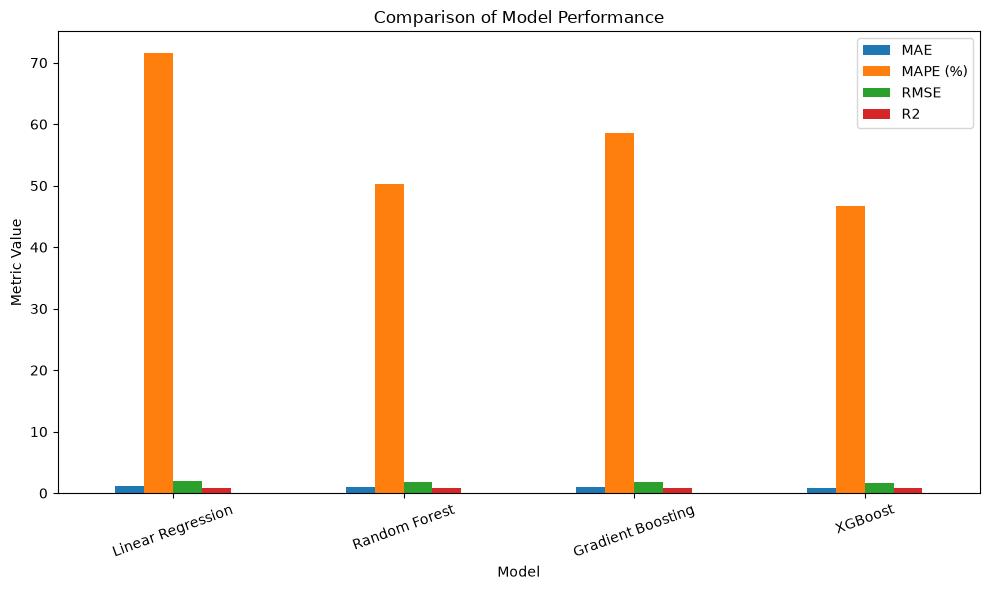

In [15]:
# Set the model names as the index
results_plot = results.set_index("Model")

# Plot evaluation metrics
results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Model Performance")
plt.ylabel("Metric Value")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.legend(loc="best")

plt.tight_layout()

# Save figure
plt.savefig("../figures/model_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Actual vs Predicted Crop Yield

This scatter plot compares the observed crop yield values with those predicted by the selected Random Forest model. Points closer to the diagonal line indicate more accurate predictions.

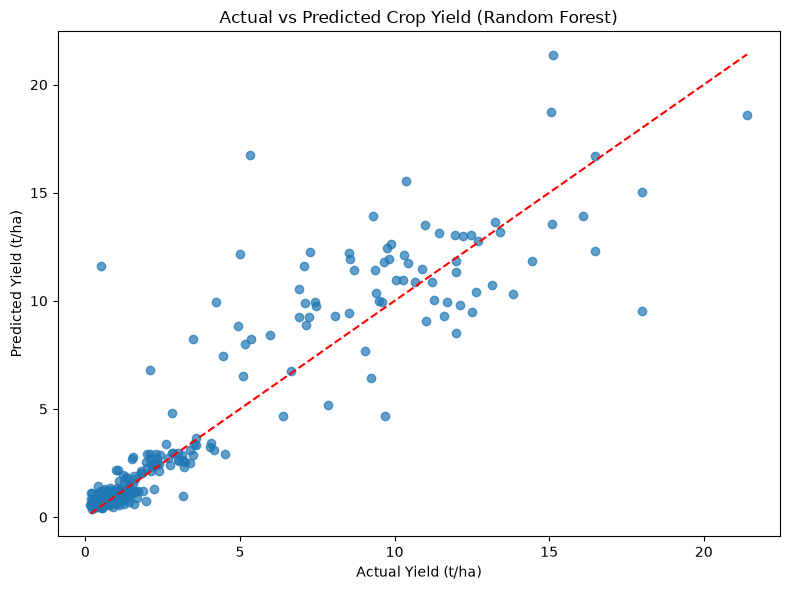

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield (t/ha)")
plt.ylabel("Predicted Yield (t/ha)")
plt.title("Actual vs Predicted Crop Yield (Random Forest)")

plt.tight_layout()

plt.savefig("../figures/random_forest_predictions.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Feature Importance

Random Forest estimates the contribution of each feature to the prediction task. Features with higher importance values have a greater influence on crop yield prediction.

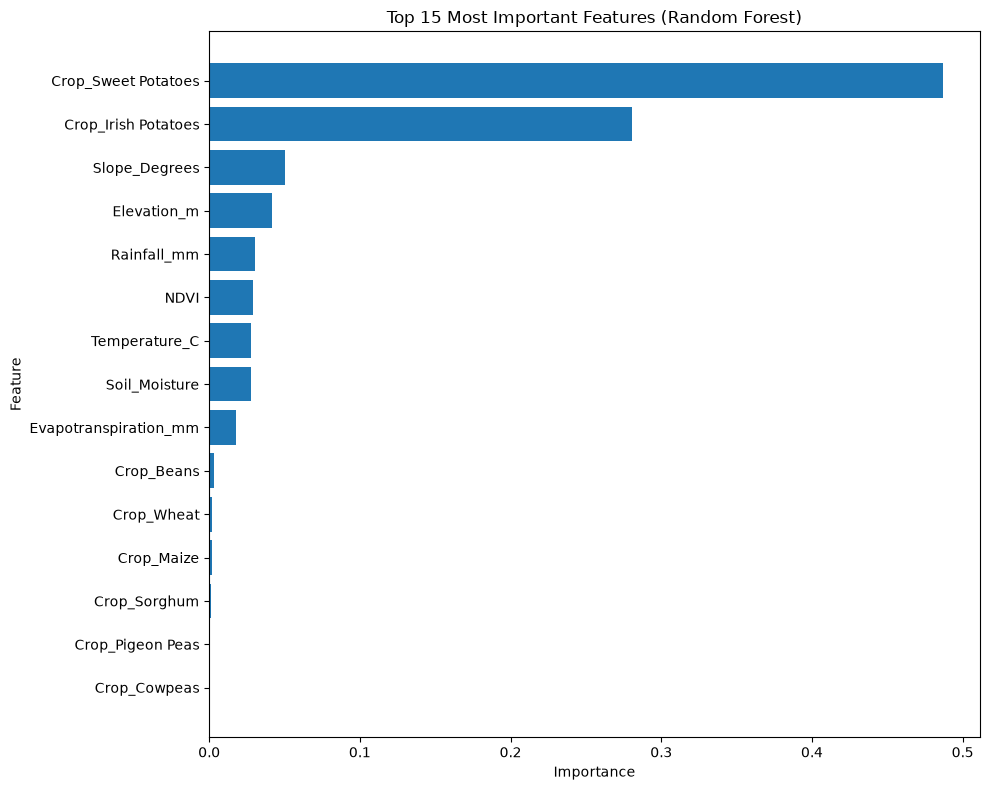

In [17]:
# Load training features for feature names
X_train = pd.read_csv("../Data/Processed_data/X_train.csv")

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)


feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features (Random Forest)")

plt.tight_layout()

plt.savefig("../figures/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()